In [171]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.linear_model import LinearRegression
import numpy as np

In [172]:
df = pd.read_csv("C:\\Coding\\hospital-bed-forecast\\data\\raw\\hospital_indonesia_datasets.csv", sep=';')
df.head(20)

,id,nama,propinsi,kab,alamat,jenis,kelas,status_blu,kepemilikan,total_tempat_tidur,total_layanan,total_tenaga_kerja
0,1110053,RS Arun Lhokseumawe,Aceh,Kota Lhokseumawe,Jl. Plaju Komplek Perumahan PT Arun Batuphat T...,Rumah Sakit Umum,C,Non BLU/BLUD,SWASTA/LAINNYA,218,36,328
1,1106014,RS Umum Fandika,Aceh,Aceh Tengah,Jl. Terminal Simpang Wariji Blangkolak 1 Kec. ...,Rumah Sakit Umum,D,Non BLU/BLUD,SWASTA/LAINNYA,45,15,45
2,1171110,RS Umum Daerah Meuraxa,Aceh,Kota Banda Aceh,Jl. Soekarno Hatta Km. 2 Desa Mibo Kecamatan B...,Rumah Sakit Umum,B,BLUD,Pemkot,310,77,487
3,1171163,RS Gigi Mulut Universitas Syiah Kuala,Aceh,Kota Banda Aceh,Jl. Prof A. Madjid Ibrahim I No. 5 Banda Aceh ...,Rumah Sakit Khusus Gigi dan Mulut,B,BLU,Kementerian Lain,11,24,0
4,1102027,RS Umum Daerah Kota Subulussalam,Aceh,Kota Subulussalam,Jl. Hamzah Fansyuri (Subulussalam-Rundeng) K...,Rumah Sakit Umum,C,BLUD,Pemkot,189,34,537
5,1106013,RS Umum Daerah Datu Beru Takengon,Aceh,Aceh Tengah,Jl. Rumah Sakit No.153 Kec. Kebayakan,Rumah Sakit Umum,B,BLUD,Pemkab,376,80,470
6,1109028,RS Umum Mufid,Aceh,Pidie,"JL. PROF. A. MAJID IBRAHIM, NO. 62-66, KEC. KO...",Rumah Sakit Umum,D,Non BLU/BLUD,Perusahaan,102,64,208
7,1174022,RS Umum Metro Medical Center,Aceh,Kota Lhokseumawe,"Jl. Merdeka Barat No. 70 A, Kecamatan Muara Du...",Rumah Sakit Umum,D,Non BLU/BLUD,SWASTA/LAINNYA,88,38,128
8,1117025,RS Umum Daerah Muyang Kute Redelong Bener Meriah,Aceh,Bener Meriah,"Jl. Simpang Teritit-Pondok Baru, Simpang Empat...",Rumah Sakit Umum,C,BLUD,Pemkab,176,35,199
9,1106025,RS Gayo Medical Centre,Aceh,Aceh Tengah,"Jl. Paya Tumpi-Mandale, No. 126 Kec. Kebayakan",Rumah Sakit Umum,D,Non BLU/BLUD,SWASTA/LAINNYA,60,56,0


In [173]:
print(f"Shape: {df.shape} || Description:  {df.describe()}")
print(f"Duplicated : {df.duplicated().sum()}")

Shape: (3155, 12) || Description:                   id  total_tempat_tidur  total_layanan  total_tenaga_kerja
count  3.155000e+03         3155.000000    3155.000000         3155.000000
mean   3.803327e+06          135.433914      41.097306          261.980666
std    2.005303e+06          550.960235      30.583893          382.352731
min    1.101015e+06            0.000000       1.000000            0.000000
25%    3.171859e+06           54.000000      22.000000           56.500000
50%    3.325039e+06          102.000000      31.000000          153.000000
75%    5.103046e+06          155.000000      50.000000          335.000000
max    9.271080e+06        30343.000000     419.000000         7939.000000
Duplicated : 0


In [174]:
for col in df.columns:
    if df[col].dtype == "str": 
        print(f"Col Name: {col} || Datatype: {df[col].dtype} || Is null %: {df[col].isnull().mean()}")
    else: 
        print(f"Col Name: {col} || Datatype: {df[col].dtype} || Is null %: {df[col].isnull().mean()} || Mean : {df[col].mean()}")

Col Name: id || Datatype: int64 || Is null %: 0.0 || Mean : 3803326.705546751
Col Name: nama || Datatype: str || Is null %: 0.0
Col Name: propinsi || Datatype: str || Is null %: 0.0
Col Name: kab || Datatype: str || Is null %: 0.0
Col Name: alamat || Datatype: str || Is null %: 0.0
Col Name: jenis || Datatype: str || Is null %: 0.0
Col Name: kelas || Datatype: str || Is null %: 0.0
Col Name: status_blu || Datatype: str || Is null %: 0.0
Col Name: kepemilikan || Datatype: str || Is null %: 0.0
Col Name: total_tempat_tidur || Datatype: int64 || Is null %: 0.0 || Mean : 135.43391442155308
Col Name: total_layanan || Datatype: int64 || Is null %: 0.0 || Mean : 41.0973058637084
Col Name: total_tenaga_kerja || Datatype: int64 || Is null %: 0.0 || Mean : 261.98066561014264


In [184]:
df['propinsi'].value_counts(dropna=False)

propinsi
Jawa Timur                   432
Jawa Barat                   421
Jawa Tengah                  354
Sumatera Utara               202
DKI Jakarta                  187
Banten                       129
Sulawesi Selatan             123
Sumatera Selatan              87
Riau                          81
Lampung                       80
Aceh                          79
Yogyakarta                    79
Bali                          79
Sumatera Barat                78
Nusa Tenggara Timur           62
Kalimantan Barat              58
Kalimantan Timur              58
Sulawesi Utara                58
Kalimantan Selatan            50
Nusa Tenggara Barat           46
Jambi                         42
Sulawesi Tengah               39
Sulawesi Tenggara             38
Kepulauan Riau                35
Kalimantan Tengah             32
Kepulauan Bangka Belitung     28
Maluku                        28
Bengkulu                      26
Maluku Utara                  22
Gorontalo                     19
K

In [175]:
df['jenis'].value_counts(dropna=False)

jenis
Rumah Sakit Umum                     2644
Rumah Sakit Khusus Ibu dan Anak       322
Rumah Sakit Khusus Jiwa                41
Rumah Sakit Khusus Mata                38
Rumah Sakit Khusus Gigi dan Mulut      34
Rumah Sakit Khusus Bedah               28
Rumah Sakit Khusus Jantung             12
Rumah Sakit Khusus Paru                 9
Rumah Sakit Khusus Orthopedi            7
Rumah Sakit Khusus THT-KL               4
Rumah Sakit Khusus Kanker               4
Rumah Sakit Khusus Ginjal               2
Rumah Sakit Khusus Infeksi              2
Rumah Sakit Khusus Stroke               1
021-26071997                            1
Rumah Sakit Khusus Otak                 1
Rumah Sakit Ketergantungan Obat         1
RS Kapal/Bergerak                       1
2                                       1
                                        1
-                                       1
Name: count, dtype: int64

In [176]:
valid_jenis = ["Rumah Sakit Umum", "Rumah Sakit Khusus Ibu dan Anak", "Rumah Sakit Khusus Jiwa", "Rumah Sakit Khusus Mata", "Rumah Sakit Khusus Gigi dan Mulut",
               "Rumah Sakit Khusus Bedah", "Rumah Sakit Khusus Jantung", "Rumah Sakit Khusus Paru", "Rumah Sakit Khusus Orthopedi", "Rumah Sakit Khusus THT-KL",
               "Rumah Sakit Khusus Kanker", "Rumah Sakit Khusus Ginjal", "Rumah Sakit Khusus Infeksi", "Rumah Sakit Khusus Stroke", "Rumah Sakit Khusus Otak",
               "Rumah Sakit Ketergantungan Obat", "RS Kapal/Bergerak"] 
invalid_mask = ~df['jenis'].isin(valid_jenis)
df.loc[invalid_mask, 'jenis'] = np.nan

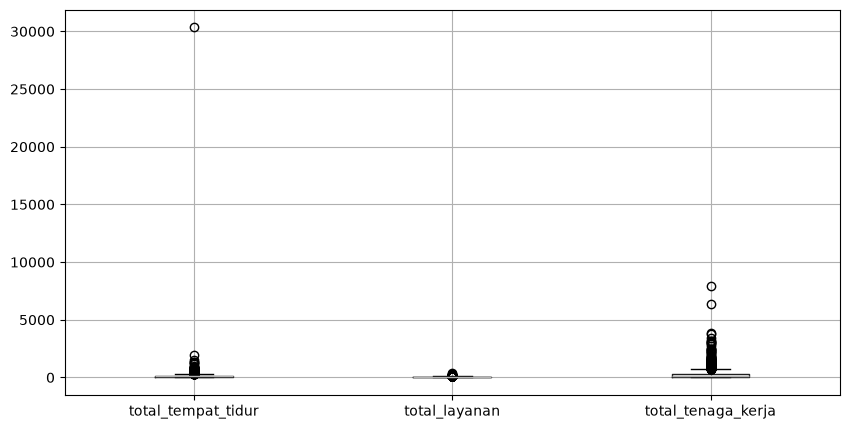

Number of outliers: 151 || Mean: 135.43391442155308 IQR: 101.0
Number of outliers: 266 || Mean: 41.0973058637084 IQR: 28.0
Number of outliers: 205 || Mean: 261.98066561014264 IQR: 278.5


In [177]:
columns_IQR = ['total_tempat_tidur', 'total_layanan', 'total_tenaga_kerja']
df[columns_IQR ].boxplot(figsize=(10, 5))
plt.show()

outlier_dict = {}

for col_name in columns_IQR:
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col_name] < lower_bound) | (df[col_name] > upper_bound)]
    print(f"Number of outliers: {len(outliers)} || Mean: {df[col_name].mean()} IQR: {IQR}")

    outlier_dict[col_name] = outliers

In [178]:
outlier_tempat_tidur = outlier_dict["total_tempat_tidur"]
outlier_tempat_tidur = outlier_tempat_tidur.sort_values("total_tempat_tidur", ascending=False)
outlier_tempat_tidur.head(10)

,id,nama,propinsi,kab,alamat,jenis,kelas,status_blu,kepemilikan,total_tempat_tidur,total_layanan,total_tenaga_kerja
1403,3310015,RS Umum Pusat Dr. Soeradji Tirtonegoro,Jawa Tengah,Klaten,"Jl. KRT. Suraji Tirtonegoro No.1, Klaten",NaN,Rumah Sakit Umum,A,BLU,30343,419,141
806,3101002,RS Umum Daerah Kepulauan Seribu,DKI Jakarta,Kepulauan Seribu,"Pulau Pramuka Rt.001 RW.004, Kelurahan : Pulau...",NaN,Rumah Sakit Umum,D,BLUD,1966,50,24
762,3173014,RSUPN Dr. Cipto Mangunkusumo,DKI Jakarta,Kota Jakarta Pusat,Jl. Diponegoro 71 Jakarta Pusat,Rumah Sakit Umum,A,BLU,Kemkes,1542,81,6325
2057,3578016,RS Umum Daerah Dr. Soetomo,Jawa Timur,Kota Surabaya,Jl. Mayjend. Prof. Dr. Moestopo No. 6 - 8 Sur...,Rumah Sakit Umum,A,BLUD,Pemprop,1311,155,7939
1746,3471085,RS Khusus Jiwa Puri Nirmala,Yogyakarta,Kota Yogyakarta,Jl Jayaningprangan No. 13 Gunungketur Pakualam...,NaN,Rumah Sakit Khusus Jiwa,C,Non BLU/BLUD,1296,27,13
3114,9228002,RS Umum Daerah Kawera,Papua,Mamberamo Raya,"Jln. Demianus Kyeuw-kyeuw, SH",NaN,Rumah Sakit Umum,D PRATAMA,Non BLU/BLUD,1220,50,20
1600,3374010,RS Umum Pusat Dr. Kariadi,Jawa Tengah,Kota Semarang,"Jl. Dr. Soetomo No.16,Semarang",Rumah Sakit Umum,A,BLU,Kemkes,1181,277,3871
1393,3372015,RS Umum Daerah Dr. Moewardi Surakarta,Jawa Tengah,Kota Surakarta,"Jl. Kol Sutarto 132,Surakarta",Rumah Sakit Umum,A,BLUD,Pemprop,953,153,3128
2041,3573011,RS Umum Daerah Dr. Saiful Anwar,Jawa Timur,Kota Malang,Jl. Jaksa Agung Suprapto No. 2 Malang,Rumah Sakit Umum,A,BLUD,Pemprop,935,157,2983
1312,3273015,RS Umum Pusat Dr. Hasan Sadikin,Jawa Barat,Kota Bandung,Jl. Pasteur No. 38 Bandung,Rumah Sakit Umum,A,BLU,Kemkes,926,81,2979


In [179]:
df = df[df["total_tempat_tidur"] < 2000]

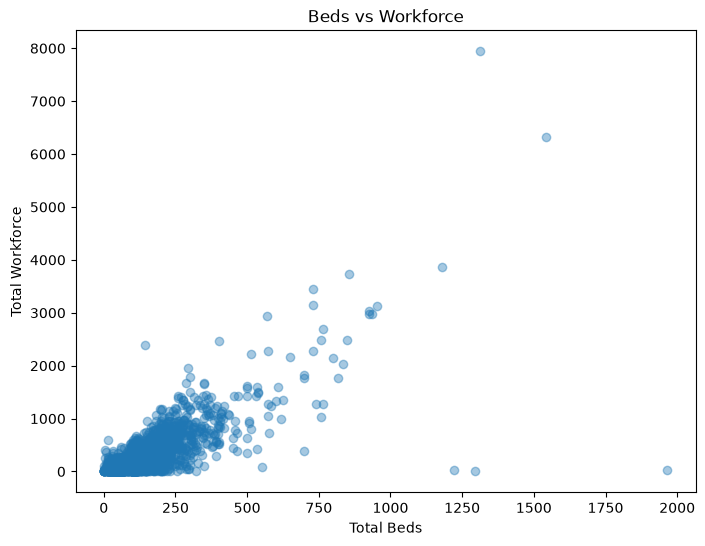

In [180]:
plt.figure(figsize=(8,6))
plt.scatter(df['total_tempat_tidur'], df['total_tenaga_kerja'], alpha=0.4)
plt.xlabel('Total Beds')
plt.ylabel('Total Workforce')
plt.title('Beds vs Workforce')
plt.show()

In [181]:
df = df[~((df['total_tempat_tidur'] > 1000) & (df['total_tenaga_kerja'] < 100))]

C:\Users\USER-PC\AppData\Local\Temp\ipykernel_24272\3627936006.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, ha='center')
C:\Users\USER-PC\AppData\Local\Temp\ipykernel_24272\3627936006.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, ha='center')
C:\Users\USER-PC\AppData\Local\Temp\ipykernel_24272\3627936006.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, ha='center')


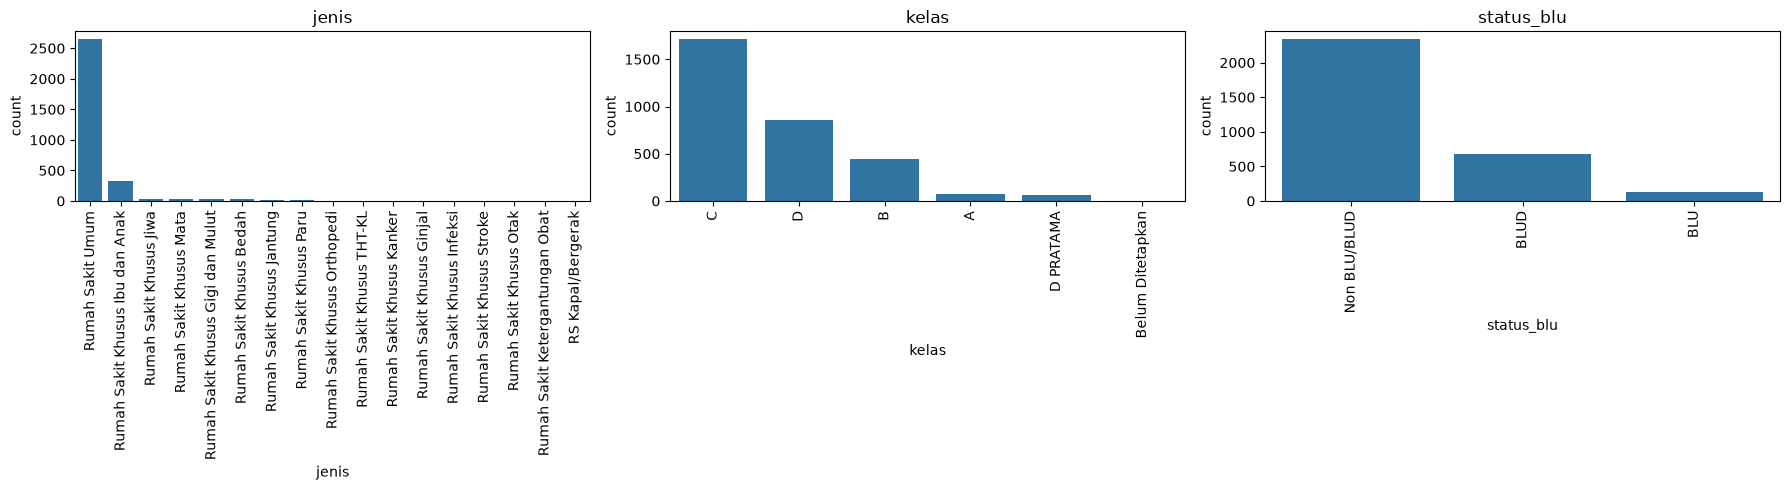

In [182]:
cat_cols = ['jenis', 'kelas', 'status_blu']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 5))

for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(col)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, ha='center')

plt.tight_layout()
plt.show()

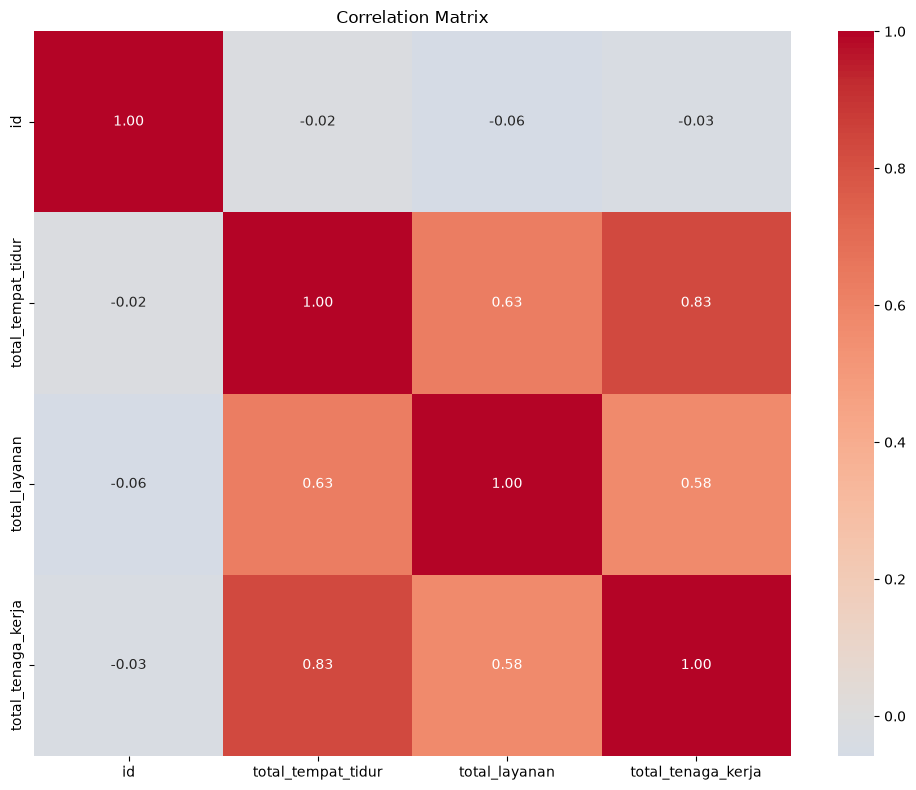

In [183]:
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()